In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [71]:
import math
import keyring
import itertools
from ast import literal_eval

In [183]:
%%html
<style>
.rendered_html p {
    font-size: 12px;
    font-family: Times New Roman, serif;
    text-align:justify}
</style>

In [25]:
# get base path for data
data_dir = keyring.get_password("msp", "vmt_reduction_dir")

In [26]:
# read in the data
# df = pd.read_csv(data_dir + "/data_processed/tbi_merged.csv")
df = pd.read_csv("../../data_processing/tbi_cleaned.csv")
df

C:\Users\yianz\AppData\Local\Temp\ipykernel_23932\2582001599.py:3: DtypeWarning: Columns (33,34,35,52,64,65,66,67,68,69,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data_processing/tbi_cleaned.csv")


,Unnamed: 0,wave,hh_id,person_id,person_num,day_num,linked_trip_id,trip_id,travel_date,travel_dow,...,transportation_barriers_4,transportation_barriers_5,transportation_barriers_997,transportation_barriers_999,day_complete,trip_survey_complete,hh_weight,person_weight,day_weight,trip_weight
0,0,1,18112062,1811206201,1,1,1.0,[1811206201001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
1,1,1,18112062,1811206201,1,1,2.0,[1811206201002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
2,2,1,18112062,1811206203,3,1,1.0,[1811206203001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
3,3,1,18112062,1811206203,3,1,2.0,[1811206203002],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
4,4,1,18112062,1811206204,4,1,1.0,[1811206204001],2018-12-06,Thursday,...,NaN,NaN,NaN,NaN,Yes,Yes,51.920180,51.920180,51.920180,51.920180
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451969,512248,2,22002790,2200279003,3,1,212556.0,[2200279003003],2022-01-27,Thursday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,20.910320,20.910320,20.910320,32.363497
451970,512249,2,22002791,2200279101,1,1,212557.0,[2200279101001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
451971,512250,2,22002791,2200279101,1,1,212558.0,[2200279101002],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499
451972,512251,2,22002791,2200279102,2,1,212559.0,[2200279102001],2022-01-26,Wednesday,...,Not selected,This has not happened in the past 7 days,Not selected,Not selected,Yes,Yes,53.032499,53.032499,53.032499,53.032499


In [27]:
# read path geopkg data
car = gpd.read_file(data_dir + "/Data_Processed/car_trips.gpkg")
bike = gpd.read_file(data_dir + "/Data_Processed/bike_trips.gpkg")
transit = gpd.read_file(data_dir + "/Data_Processed/transit-trips.gpkg")
walk = gpd.read_file(data_dir + "/Data_Processed/walk_trips.gpkg")

In [ ]:
# preprocess bike

In [173]:
# wave 2 trips missing?
bike.trip_id.str[1:3].value_counts()

19    163693
18     90474
Name: trip_id, dtype: int64

In [ ]:
# preprocess transit

In [174]:
# some transit trips lack corresponding trip data
display(df[df["trip_id"] == '[1811541101009, 1811541101010, 1811541101011, 1811541101012]']["mode"]) # this trip is transit
display(transit[transit["trip_id"].str.contains("1811541101009")]) # can't find any transit trip containing the trip id

186    Transit
Name: mode, dtype: object

,trip_id,leg_index,start_time,end_time,origin_stop_id,origin_stop_name,destination_stop_id,destination_stop_name,route_id,route_short_name,route_long_name,route_type,leg_type,geometry,start_time_dt,end_time_dt,duration


In [ ]:
# calculate duration from star/tend times
transit["start_time_dt"] = pd.to_datetime(transit["start_time"])
transit["end_time_dt"] = pd.to_datetime(transit["end_time"])

transit["duration"] = (transit["end_time_dt"] - transit["start_time_dt"]).apply(lambda x: x.seconds / 60)

In [ ]:
# create a gdf for linked trips
agg_fns = {
    "trip_id": "first",
    "leg_index": "count",
    "start_time": "first",
    "end_time": "last",
    "origin_stop_id": "first", # throw away
    "origin_stop_name": "first",
    "destination_stop_id": "first",
    "destination_stop_name": "first",
    "route_id": "first", 
    "route_short_name": "first",
    "route_long_name": "first",
    "route_type": "first", 
    "leg_type": "first", # end throw away
    "start_time_dt": "first",
    "end_time_dt": "last",
    "duration": "sum"
}

transit_grouped = transit.dissolve(by="trip_id", aggfunc=agg_fns) # merges geometries in addition to aggregating the rest of the columns

In [28]:
def plot_density(column: pd.Series, percentile=0.95, discrete=False, bins=100, size=(12, 6)):
    fig, ax = plt.subplots(figsize=size)
    sns.histplot(column, ax=ax, discrete=discrete, bins=bins, kde=True, stat="density")
    val = column.quantile(q=percentile)
    plt.axvline(x=val, color="red")
    return fig, ax

### duration analysis

In [30]:
## overall summary statistics
df["duration"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    451974.000000
mean         18.964511
std          21.713015
min           0.100000
25%           8.233333
50%          13.933333
75%          22.916667
95%          48.600000
max         970.516667
Name: duration, dtype: float64

(0.0, 200.0)

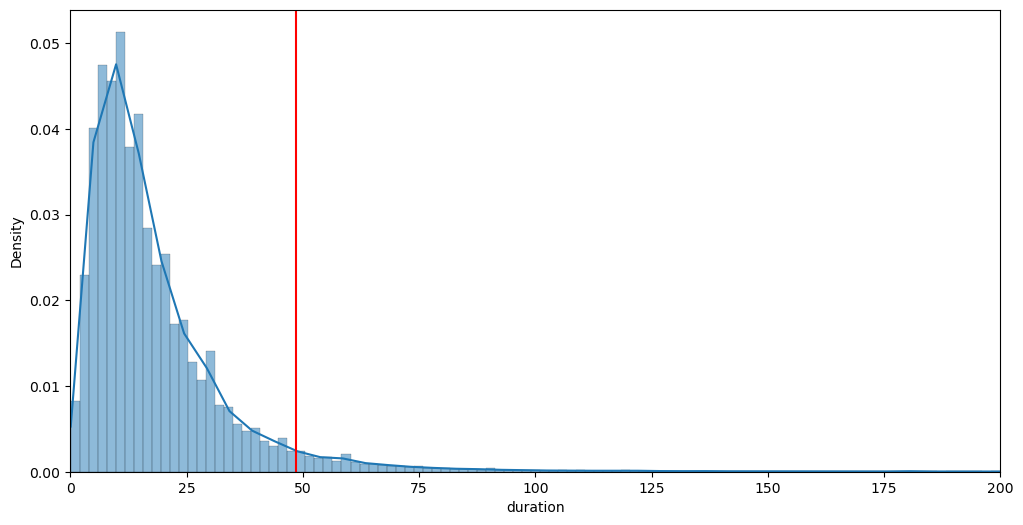

In [31]:
# overall distribution of duration
# there are repetitive peaks, likely since the temporal resolution is discrete with respect ot minutes
fig, ax = plot_density(df["duration"], bins=500)
ax.set_xlim(left=0, right=200) # cutoff upper end, there are some outliers that make the graph hard to read

Text(0.5, 0, 'log duration')

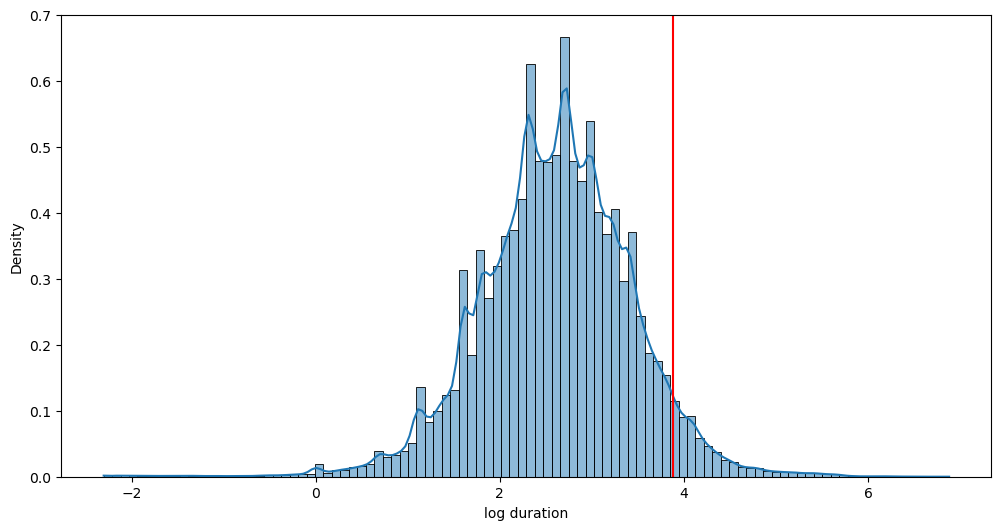

In [32]:
# overall distribution of the log of duration
fig, ax = plot_density(np.log(df["duration"]), bins=100)
ax.set_xlabel("log duration")

In [33]:
## duration analysis segmented by mode

In [34]:
df["mode"].value_counts()

Car                       377333
Walk                       50134
Transit                    11279
Bike/Scooter                7705
School bus                  3668
Taxi/Ridehail/Carshare      1855
Name: mode, dtype: int64

In [35]:
# currently ignore schools bus and taxi/ridehail/carshare -- can decide whether to omit or group with others later
# with school buses, we might need analysis for school-age children only since school buses aren't a widely available mode to the public
# with taxi/ridehail/carshare, could be transit but it is very distinct, possibly omit or add as another option
df_mode_cleaned = df[~df["mode"].isin(["School bus", "Taxi/Ridehail/Carshare"])]

In [233]:
def plot_mode_density(df: pd.DataFrame, key: str, percentile=0.95, size=(12, 6), bins=300, function=lambda x: x):
    palette = itertools.cycle(sns.color_palette()) # cycle through colors to make sure each mode gets a unique one
    fig, ax = plt.subplots(figsize=size)
    for mode in df["mode"].value_counts().index: # cycle through all modes
        c = next(palette) # get color to use
        group = df[df["mode"] == mode] # filter out the current mode
        sns.histplot(function(group[key]), ax=ax, stat="density", kde=True, label=mode, color=c, bins=bins) # plot hist plot with kde overlayed in the color
        val = function(group[key]).quantile(q=percentile) # calculate the value of the given percentile (default 0.95)
        plt.axvline(x=val, color=c) # plot line representing that value on the plot
    return fig, ax

In [37]:
def show_summaries(df: pd.DataFrame, key: str, percentile=0.95): # show normal summaries for each mode side by side
    res = []
    p = [0.25, 0.5, 0.75]
    p.append(percentile)
    for mode in df["mode"].value_counts().index:
        group = df[df["mode"] == mode]
        res.append(group[key].describe(percentiles=p))
    x = pd.concat(res, axis=1)
    x.columns = df["mode"].value_counts().index
    return x

In [38]:
show_summaries(df_mode_cleaned, "duration")

,Car,Walk,Transit,Bike/Scooter
count,377333.000000,50134.000000,11279.000000,7705.000000
mean,18.542229,16.149813,38.154242,23.640117
std,21.044895,18.693085,29.783879,25.802185
min,0.100000,0.100000,0.133333,0.133333
25%,8.333333,6.433333,20.000000,9.000000
50%,13.816667,11.450000,32.033333,16.083333
75%,22.350000,19.466667,48.391667,29.050000
95%,46.050000,42.200000,85.260000,66.286667
max,970.516667,325.466667,570.000000,325.800000


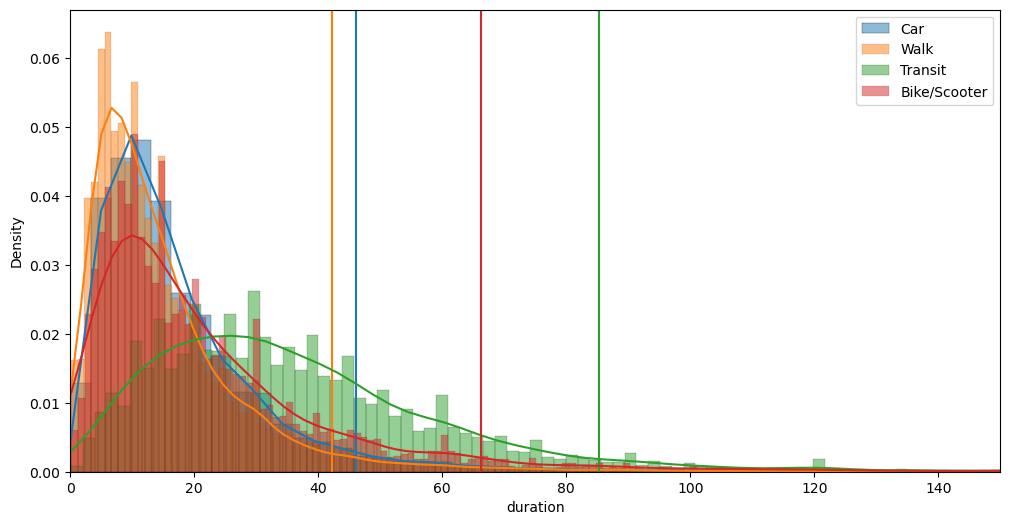

In [234]:
# plot of densities of all modes overlayed on top of one another
fig, ax = plot_mode_density(df_mode_cleaned, "duration")
ax.set_xlim(left=0, right=150)
plt.legend()

takeaways:

- durations tend to be right-skewed; people prefer shorter durations
- walk durations tend to be the shortest, followed by car, biking, and transit in that order
- there is small bias in durations as it is semi-categorical, with multiple peaks/non-continuous distribution
- the transit duration distribution deviates significantly from the other modes--transit riders are less sensitive to duration
- there remain some duration outliers

further analysis:
- trip duration as a percentage of the total trip time

### difference between driving and non-driving mode durations

In [184]:
# overall

difference_with_car_duration = df_mode_cleaned[df_mode_cleaned["mode"] != "Car"]["duration"] - (car.set_index("trip_id").loc[df_mode_cleaned[(df_mode_cleaned["mode"] != "Car")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 150.0)

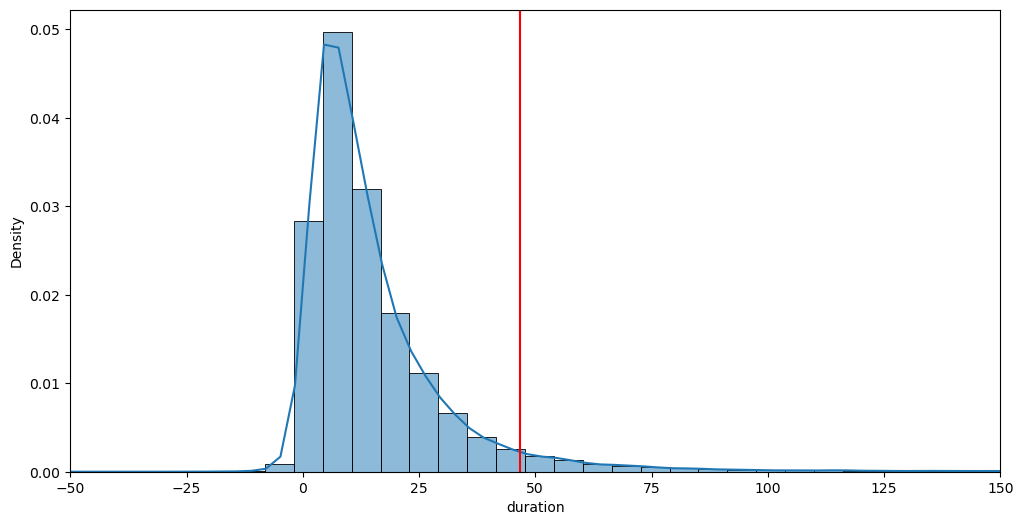

In [191]:
fig, ax = plot_density(difference_with_car_duration)
ax.set_xlim(left=-50, right=150)

In [194]:
difference_with_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    69118.000000
mean        16.152061
std         20.882794
min        -51.665000
25%          5.433333
50%         10.733333
75%         19.591250
95%         46.675250
max        570.000000
Name: duration, dtype: float64

In [197]:
# percent of all non-car trips that are faster than car
(difference_with_car_duration <= 0).sum() / len(difference_with_car_duration)

0.023597326311525217

In [41]:
# bike vs car

In [61]:
# for each bike trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these bikers tradeoff between car & bike duration
bike_minus_car_duration = df_mode_cleaned[df_mode_cleaned["mode"] == "Bike/Scooter"]["duration"] - (car.set_index("trip_id").loc[df_mode_cleaned[(df_mode_cleaned["mode"] == "Bike/Scooter")]["trip_id"].values].duration_seconds / 60).values

In [62]:
# not sure if it would be feasible to switch to bike if car is 53 minutes faster
# self sampling likely plays a role -- maybe adopt a smaller percentile to adjust?
bike_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    7705.000000
mean       16.805448
std        23.208526
min       -11.326667
25%         5.136667
50%        10.326667
75%        19.445000
95%        53.201667
max       303.550000
Name: duration, dtype: float64

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='duration', ylabel='Density'>)

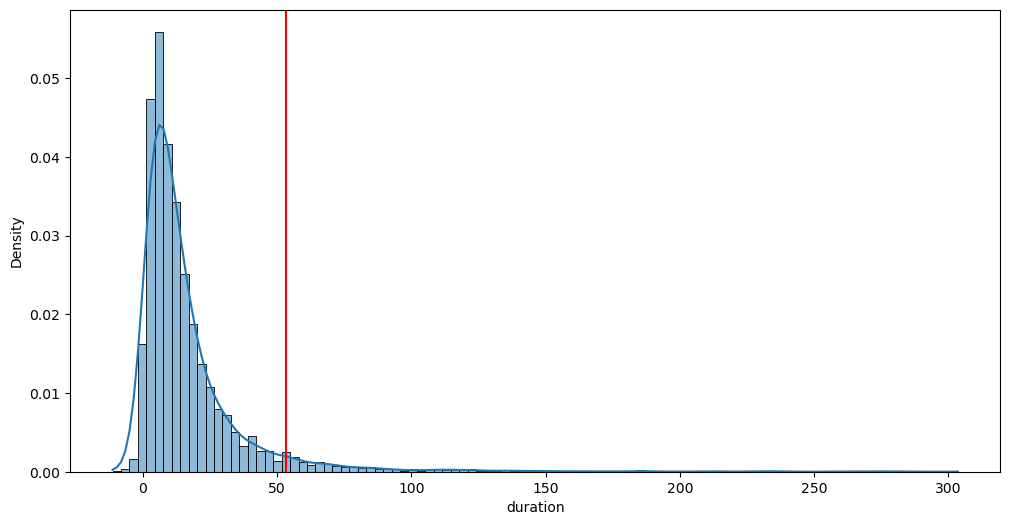

In [63]:
plot_density(bike_minus_car_duration)

In [ ]:
# transit vs car

In [178]:
# for each transit trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how these transit riders tradeoff between car & transit duration

transit_minus_car_duration = df_mode_cleaned[df_mode_cleaned["mode"] == "Transit"]["duration"] - \
    (car.set_index("trip_id").loc[df_mode_cleaned[(df_mode_cleaned["mode"] == "Transit")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 200.0)

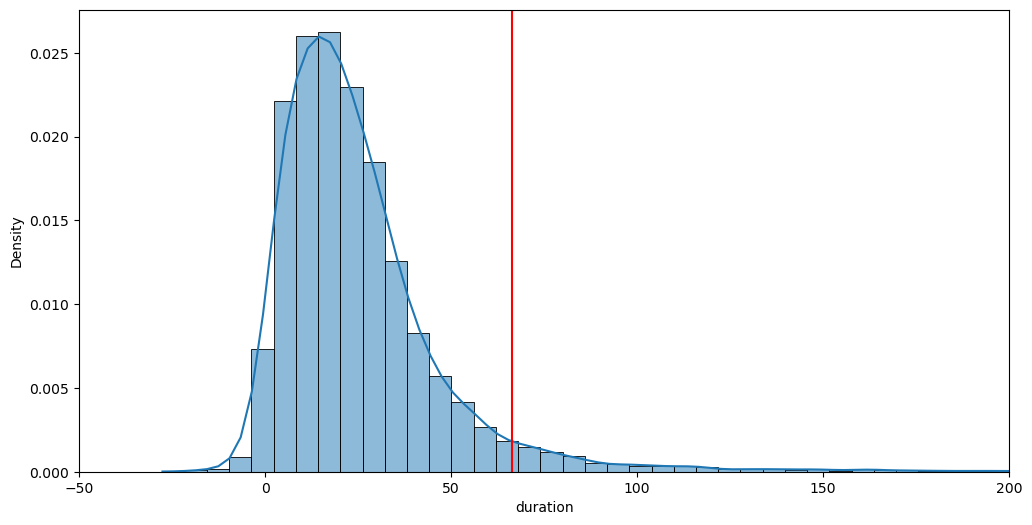

In [168]:
# positive means car duration < transit and vice versa
fig, ax = plot_density(transit_minus_car_duration)
ax.set_xlim(left=-50, right=200)

In [172]:
transit_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    11279.000000
mean        25.941877
std         26.901623
min        -27.603333
25%         10.948333
50%         20.401667
75%         32.680000
95%         66.365333
max        570.000000
Name: duration, dtype: float64

In [88]:
# walk vs car

,trip_id,duration_seconds,distance_meters,weight,geometry
0,[1811206201001],7591.0,31387.0,7591.0,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
1,[1811206201002],7582.7,31336.2,7582.7,"LINESTRING (-92.91716 44.51007, -92.91715 44.5..."
2,[1811206203001],3692.7,15091.5,3692.7,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
3,[1811206203002],3698.1,15130.2,3698.1,"LINESTRING (-92.88609 44.73583, -92.88572 44.7..."
4,[1811206204001],3507.4,14339.8,3507.4,"LINESTRING (-92.76557 44.65391, -92.76603 44.6..."
...,...,...,...,...,...
254162,[1978065201003],2919.9,11176.7,2919.9,"LINESTRING (-93.27403 44.95817, -93.27421 44.9..."
254163,[1978065201004],1692.8,6752.1,1692.8,"LINESTRING (-93.31773 44.88368, -93.31711 44.8..."
254164,[1978065201005],1441.1,5214.7,1441.1,"LINESTRING (-93.31231 44.83236, -93.31182 44.8..."
254165,[1978065202001],1862.8,6534.8,1862.8,"LINESTRING (-93.36343 44.82592, -93.36347 44.8..."


In [177]:
# for each walk trip, calculate the corresponding duration it would take to do it via car
# this should tell something about how walkers tradeoff between car & walk duration

walk_minus_car_duration = df_mode_cleaned[df_mode_cleaned["mode"] == "Walk"]["duration"] - \
    (car.set_index("trip_id").loc[df_mode_cleaned[(df_mode_cleaned["mode"] == "Walk")]["trip_id"].values].duration_seconds / 60).values

(-50.0, 150.0)

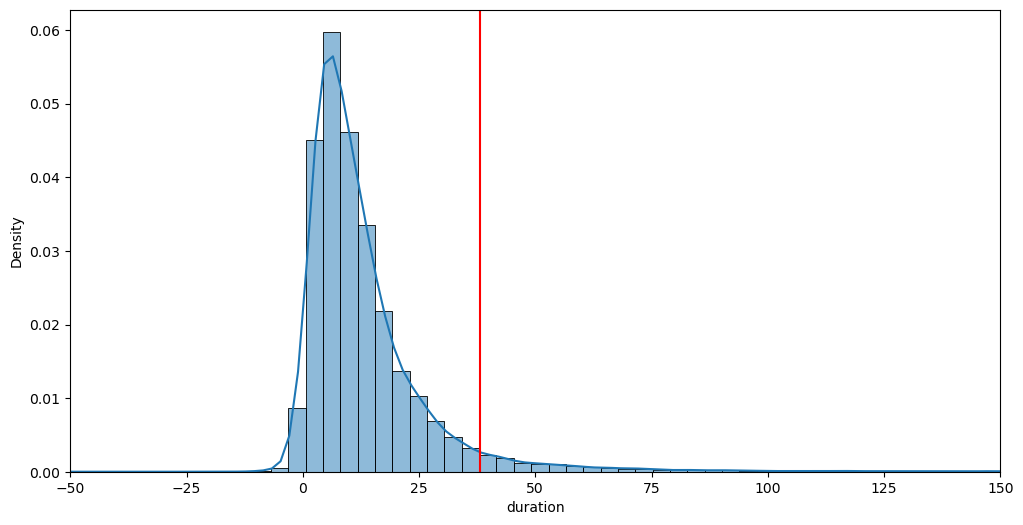

In [193]:
# positive means car duration < transit and vice versa
fig, ax = plot_density(walk_minus_car_duration)
ax.set_xlim(left=-50, right=150)

In [192]:
walk_minus_car_duration.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    50134.000000
mean        13.849159
std         18.130597
min        -51.665000
25%          5.036667
50%          9.444167
75%         16.567917
95%         38.075750
max        321.598333
Name: duration, dtype: float64

duration difference takeaways

- the distributions for duration difference between mode and car are remarkably similar, with 95 percnetiles around 40-60
- none of these modes can beat out car (and it doesn't even seem close--the amount of trips in each mode where this mode is faster is like 1% for each), so there are some other factors other than duration that drive these people to use these modes
    - this could be due to selection bias -- people who use these modes are "enthusiasts," so a smaller percentile may be needed to account for this

further analysis
- could try a duration percentage analysis as well to standardize duration magnitudes

### distance analysis

In [ ]:
# overall

In [199]:
# summary statistics
df["distance"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    451974.000000
mean          6.265382
std           8.274941
min           0.010238
25%           1.180789
50%           3.232732
75%           8.103433
95%          22.148011
max          99.978130
Name: distance, dtype: float64

(0.0, 50.0)

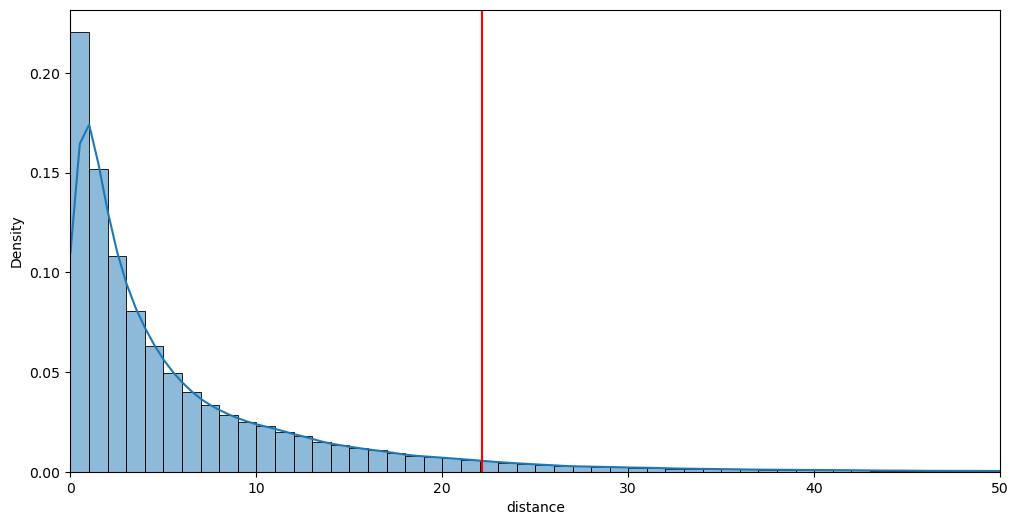

In [201]:
# distribution
fig, ax = plot_density(df["distance"])
ax.set_xlim(left=0, right=50) # max is 99, cut off about half

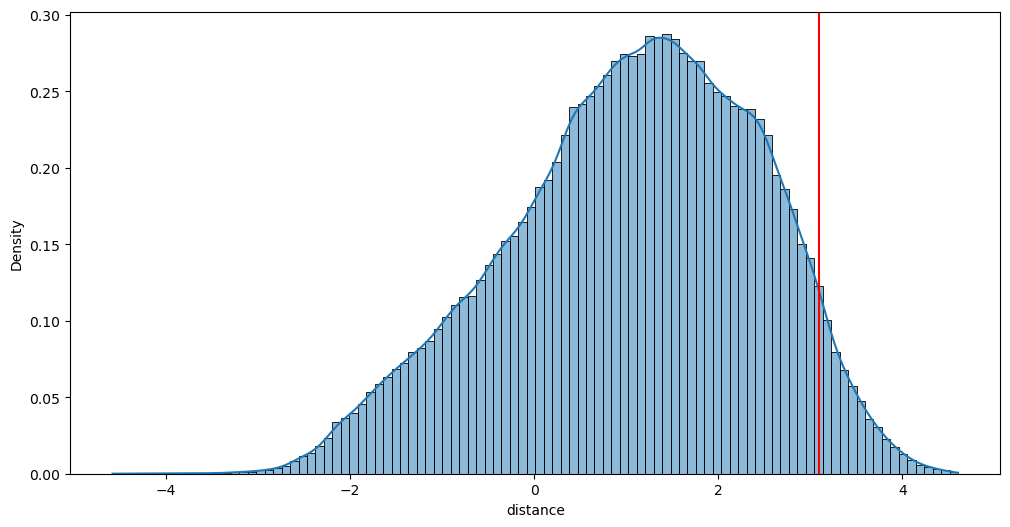

In [202]:
# log distance distribution
# compared with the overall distribution, we see more resolution in the shorter distance trips, which make up a significant portion of all trips
fig, ax = plot_density(np.log(df["distance"]))

In [205]:
# segmented by mode

In [237]:
show_summaries(df_mode_cleaned, key="distance")

,Car,Walk,Transit,Bike/Scooter
count,377333.000000,50134.000000,11279.000000,7705.000000
mean,7.070595,0.698849,6.968255,3.233572
std,8.618728,1.239752,7.469740,4.219710
min,0.024010,0.010238,0.025480,0.057926
25%,1.678135,0.213500,2.151295,0.831384
50%,3.973360,0.397094,4.418200,1.853217
75%,9.262450,0.760542,8.841020,4.052120
95%,23.540784,2.040692,22.071148,10.535152
max,99.978130,55.865006,70.046313,80.358668


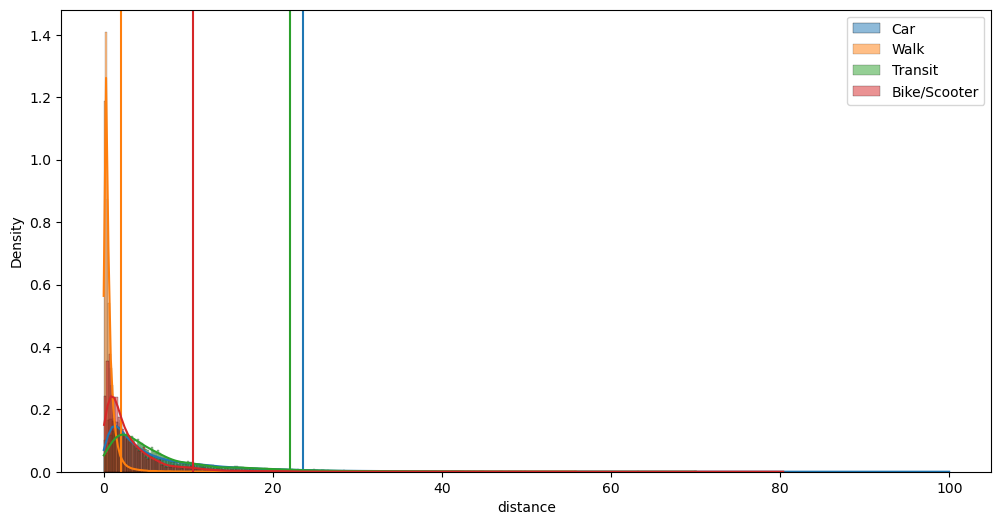

In [238]:
# raw distance distribution (miles)
fig, ax = plot_mode_density(df_mode_cleaned, key="distance") # this is meaningless
plt.legend()

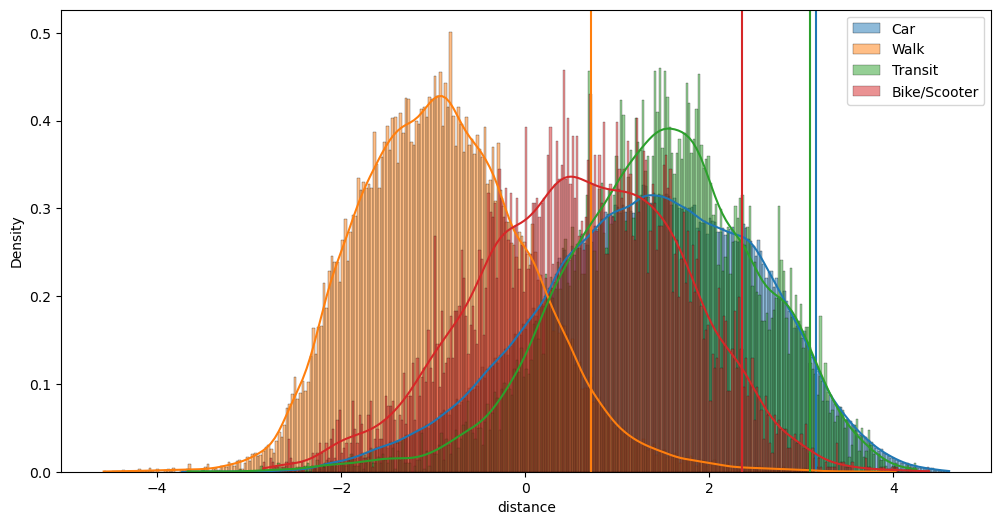

In [235]:
# log distance distribution
fig, ax = plot_mode_density(df_mode_cleaned, key="distance", function=np.log)
plt.legend()

distance takeaways

- honestly pretty straight forward, not anything surprising
- more continuous than duration, has a continuous decline from 0 distance trips, very much right skewed
    - people prefer shorter distance trips
- car and transit distance distributions are relatively similar -- transit & car riders have relatively similar sensitivies to distance
- walk trips are generally about 1 mile or less
- bike/scooter trips are a middle ground between car/transit and walk

further analysis
- we could do a distance vs car analysis but this probably wouldn't show much--difference between walking around a square and cutting through the middle
- maybe distance in certain areas? like cbd vs suburban or something


### season

(i don't think we can get weather)

In [264]:
df["month"] = df["travel_date"].str[5:7]
df_mode_cleaned.loc["month", :] = df_mode_cleaned["travel_date"].str[5:7]

In [285]:
def map_to_season(month):
    # can change to a more granular definition
    match month:
        case '12' | '01' | '02':
            return "winter"
        case '03' | '04' | '05':
            return "spring"
        case '06' | '07' | '08':
            return "summer"
        case _:
            return "autumn"

In [286]:
df["season"] = df["month"].apply(map_to_season)
df_mode_cleaned["season"] = df_mode_cleaned["month"].apply(map_to_season)

<Axes: xlabel='season', ylabel='count'>

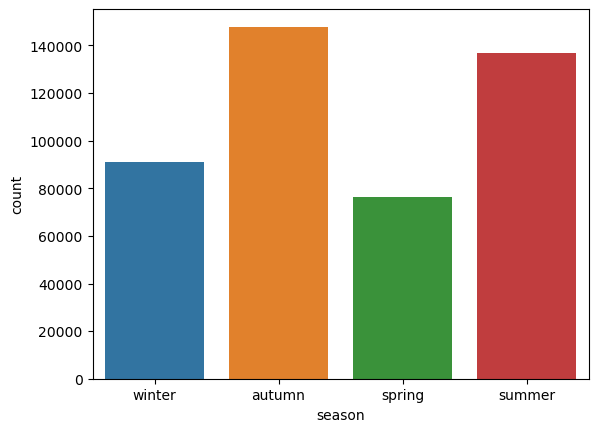

In [288]:
# distribution of season
# WARNING: this could be biased due to the timespan of the data collection -- some season may have been cut short
sns.countplot(x="season", data=df)

In [289]:
# season distribution by mode

In [310]:
def plot_mode_barplot(df: pd.DataFrame, key: str, mode:str, func=lambda x: x, figsize=(7, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=df[key].value_counts().sort_index().index, y=func(df[df["mode"] == mode][key].value_counts().sort_index()), ax=ax)
    return fig, ax

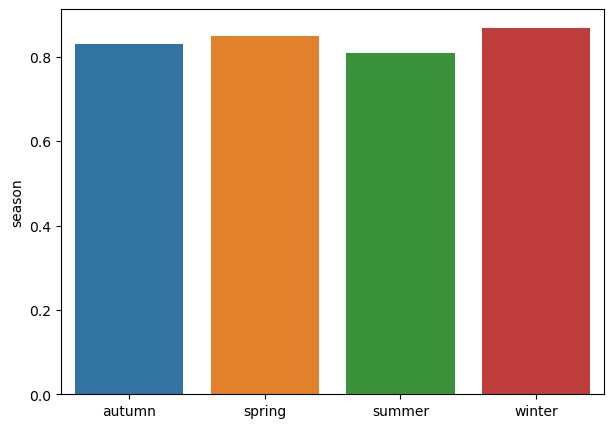

In [313]:
# car seasons
# little variation in car trip % between seasons aside from a slight dip in the summer and slight bump in winter
fig, ax = plot_mode_barplot(df_mode_cleaned, "season", "Car", lambda x: x / df["season"].value_counts())

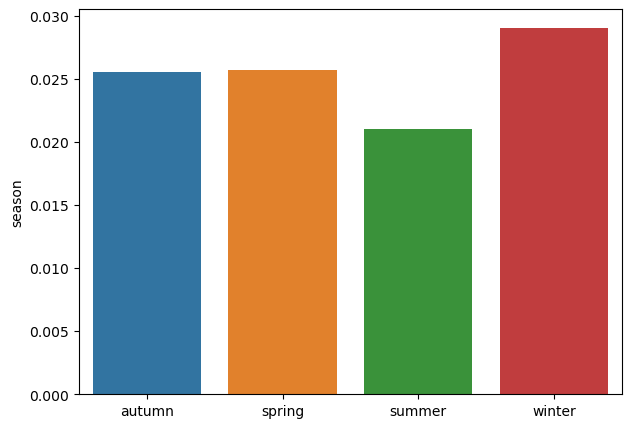

In [312]:
# transit seasons
# significant summer dip & somewhat significant winter bump (possibly due to unsafe conditions otherwise?)
fig, ax = plot_mode_barplot(df_mode_cleaned, "season", "Transit", lambda x: x / df["season"].value_counts())

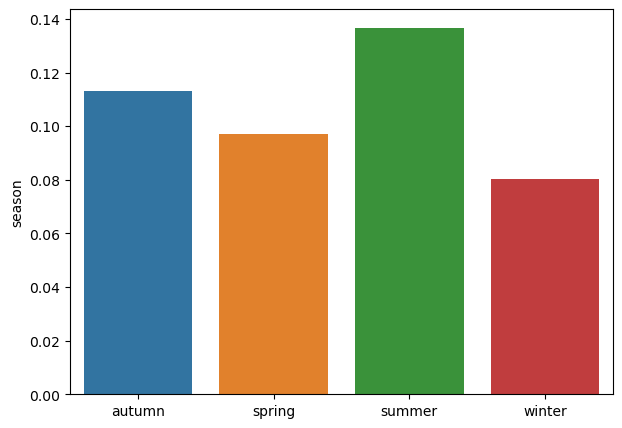

In [314]:
# walk seasons
# significant summer bump & significant winter dip
fig, ax = plot_mode_barplot(df_mode_cleaned, "season", "Walk", lambda x: x / df["season"].value_counts())

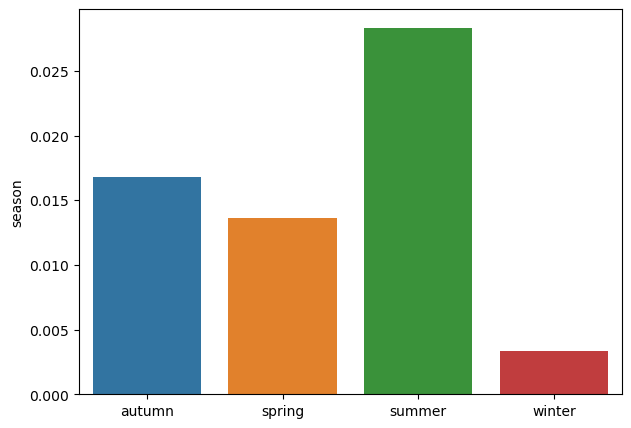

In [315]:
# bike season
# very significant summer bump & very significant winter dip
# basically walk but more extreme variation
fig, ax = plot_mode_barplot(df_mode_cleaned, "season", "Bike/Scooter", lambda x: x / df["season"].value_counts())

takeaways

- seasons do seem to play a large part in the relative proportions of mode trips for non-driving modes
    - comparing relative proportions in distance should be able to handle the sampling timing bias
    - this effect is very pronounced for walking and biking

future analysis
- how do we apply a 95% rule for categorical variables? -- probably need an alternative feasibility indicator
    - could just cut out extreme dips -- e.g., people don't bike in winter
- more granular season definitions
- include weather/ temperature (continuous data) / wind speed / other climate data somehow
    - could just extract average temperatures of the area